<a href="https://colab.research.google.com/github/fael83/Smt4-Data-Mining/blob/main/Week13_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [4]:
# Load dataset
from sklearn.datasets import make_blobs, load_iris
iris = load_iris()
X_iris = iris.data
iris_features = iris.feature_names
df_iris = pd.DataFrame(X_iris, columns=iris_features)


In [7]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(df_iris)

/tmp/ipykernel_1783/2511862176.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(K_iris, inertia_iris, 'ro-', color='darkred')


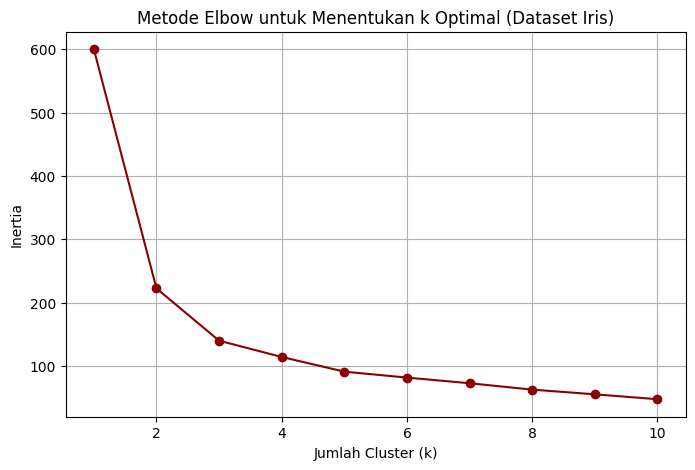

In [8]:
# Grafik Elbow Method
inertia_iris = []
K_iris = range(1, 11)

for k in K_iris:
    kmeans_iris = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_iris.fit(X_iris_scaled)
    inertia_iris.append(kmeans_iris.inertia_)

# Grafik elbow
plt.figure(figsize=(8, 5))
plt.plot(K_iris, inertia_iris, 'ro-', color='darkred')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk Menentukan k Optimal (Dataset Iris)')
plt.grid(True)
plt.show()

In [10]:
# Buat model KMeans
k_optimal_iris = 3
kmeans_iris_opt = KMeans(n_clusters=k_optimal_iris, random_state=42, n_init=10)
df_iris['Cluster'] = kmeans_iris_opt.fit_predict(X_iris_scaled)

# Lihat hasil clustering
print(df_iris.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


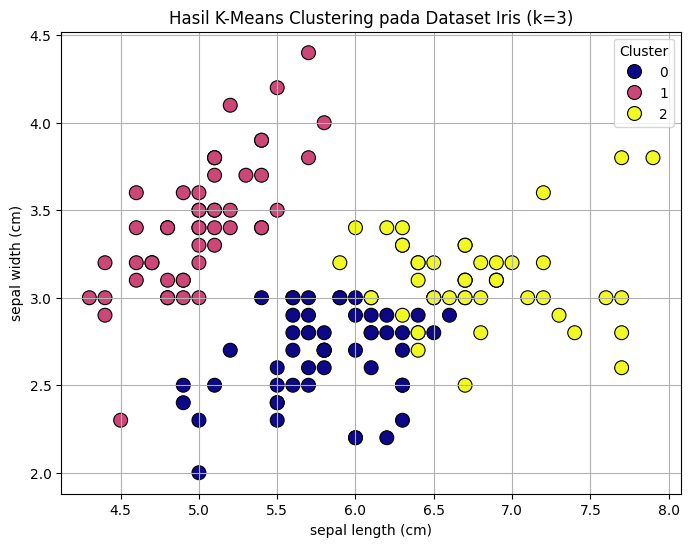

In [11]:
# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_iris.iloc[:, 0], y=df_iris.iloc[:, 1], hue=df_iris['Cluster'], palette='plasma', s=100, edgecolor='k')
plt.title('Hasil K-Means Clustering pada Dataset Iris (k=3)')
plt.xlabel(iris_features[0])
plt.ylabel(iris_features[1])
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [14]:
# Menampilkan hasil silhoutte score dan inertia akhir
silhouette_iris = silhouette_score(X_iris_scaled, df_iris['Cluster'])
print(f"\nSilhouette Score: {silhouette_iris:.4f}")
print(f"Inertia (k=3): {k_optimal_iris}")


Silhouette Score: 0.4599
Inertia (k=3): 3
